# **✅ Step 1: Load and Clean the Dataset**

In [ ]:
import pandas as pd

df = pd.read_csv(r"D:\Skillify Zone Intern\Sample_ Superstore.csv", encoding='latin1')
print(df.info())
print("\nMissing values before cleaning:")
print(df.isnull().sum())

df.dropna(inplace=True)

df['Order Date'] = pd.to_datetime(df['Order Date'])
df['Ship Date'] = pd.to_datetime(df['Ship Date'])


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9994 non-null   int64  
 1   Order ID       9994 non-null   object 
 2   Order Date     9994 non-null   object 
 3   Ship Date      9994 non-null   object 
 4   Ship Mode      9994 non-null   object 
 5   Customer ID    9994 non-null   object 
 6   Customer Name  9994 non-null   object 
 7   Segment        9994 non-null   object 
 8   Country        9994 non-null   object 
 9   City           9994 non-null   object 
 10  State          9994 non-null   object 
 11  Postal Code    9994 non-null   int64  
 12  Region         9994 non-null   object 
 13  Product ID     9994 non-null   object 
 14  Category       9994 non-null   object 
 15  Sub-Category   9994 non-null   object 
 16  Product Name   9994 non-null   object 
 17  Sales          9994 non-null   float64
 18  Quantity

# **🔍 Step 2: Exploratory Data Analysis (EDA)**

### **Example 1: Best Selling Category**

In [18]:
category_sales = df.groupby('Category')['Sales'].sum().sort_values(ascending=False)
print(category_sales)

Category
Technology         836154.0330
Furniture          741999.7953
Office Supplies    719047.0320
Name: Sales, dtype: float64


### **Example 2: Region with Highest Profit**

In [19]:
region_profit = df.groupby('Region')['Profit'].sum().sort_values(ascending=False)
print(region_profit)

Region
West       108418.4489
East        91522.7800
South       46749.4303
Central     39706.3625
Name: Profit, dtype: float64


# **📊 Step 3: Visualize Key Insights**

In [28]:
import matplotlib.pyplot as plt
import seaborn as sns

### **Best Selling Categories**

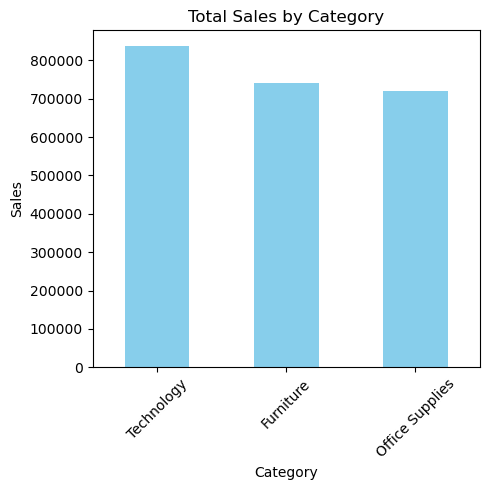

In [44]:
plt.figure(figsize=(5,5))
category_sales.plot(kind='bar', color='skyblue')
plt.title('Total Sales by Category')
plt.ylabel('Sales')
plt.xlabel('Category')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### **Profits by Region**

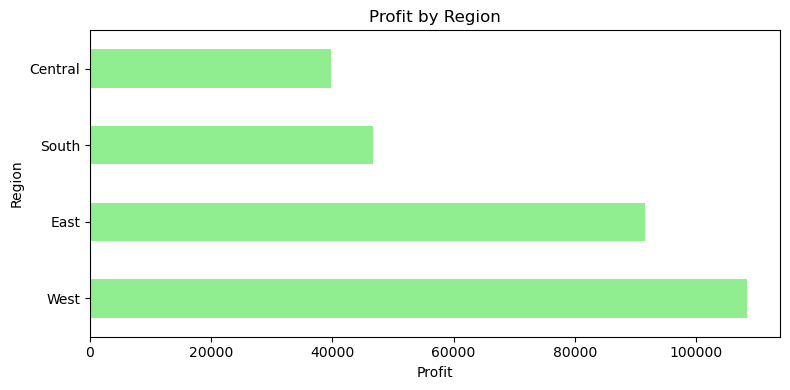

In [41]:
plt.figure(figsize=(8,4))
region_profit.plot(kind='barh', color='lightgreen')
plt.title('Profit by Region')
plt.xlabel('Profit')
plt.ylabel('Region')
plt.tight_layout()
plt.show()

### **Monthly Sales Trend**

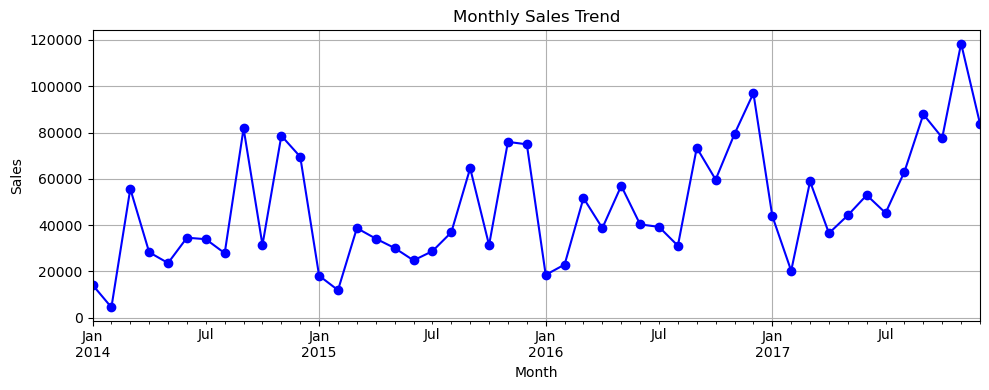

In [56]:
df['Month'] = df['Order Date'].dt.to_period('M')
monthly_sales = df.groupby('Month')['Sales'].sum()

monthly_sales.plot(figsize=(10,4), marker='o', color='blue')
plt.title("Monthly Sales Trend")
plt.ylabel("Sales")
plt.xlabel("Month")
plt.grid(True)
plt.tight_layout()
plt.show()


### **Heatmap of correlation**

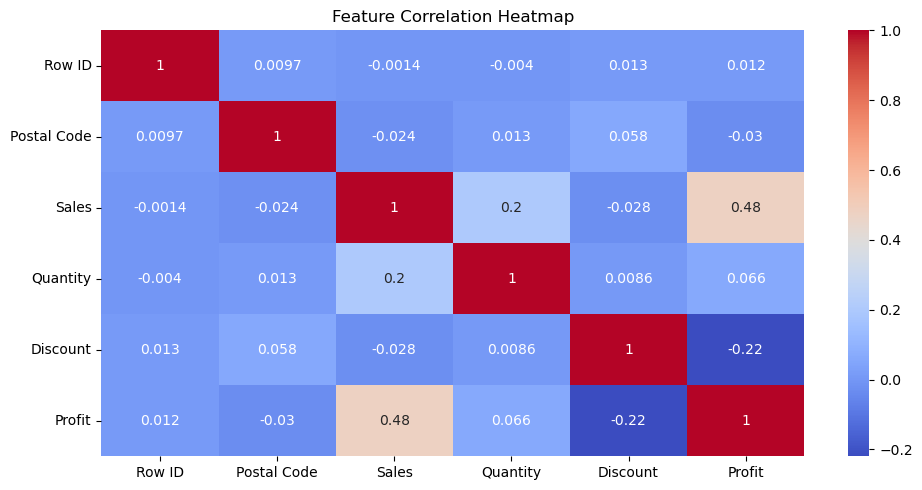

In [57]:
plt.figure(figsize=(10,5))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title("Feature Correlation Heatmap")
plt.tight_layout()
plt.show()